In [10]:
# ============================================================
# IMPORTACIONES
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# CONFIGURACIÓN VISUAL
# ============================================================

plt.rcParams["figure.figsize"] = (14, 6)


# ============================================================
# CARGA DATASET
# ============================================================

df = pd.read_parquet(
    "../data/processed/bdlona_logs.parquet"
)


# ============================================================
# INFORMACIÓN GENERAL
# ============================================================

print(df.shape)

display(df.head())


# ============================================================
# TIPOS DE DATOS
# ============================================================

df.info()


# ============================================================
# ESTADÍSTICAS BÁSICAS
# ============================================================

df.describe()

(95878, 9)


,datetime,spot,temperature,wind_direction_deg,wind_avg,wind_min,wind_max,unknown,source_file
0,2021-01-01 07:00:03,BDLONA,9,359,0,0,1,1,210101.log
1,2021-01-01 07:15:10,BDLONA,9,266,1,0,5,1,210101.log
2,2021-01-01 07:30:05,BDLONA,9,268,1,0,5,1,210101.log
3,2021-01-01 07:45:01,BDLONA,9,303,0,0,4,1,210101.log
4,2021-01-01 08:00:06,BDLONA,9,342,2,0,6,1,210101.log


<class 'pandas.DataFrame'>
RangeIndex: 95878 entries, 0 to 95877
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   datetime            95878 non-null  datetime64[us]
 1   spot                95878 non-null  str           
 2   temperature         95878 non-null  int64         
 3   wind_direction_deg  95878 non-null  int64         
 4   wind_avg            95878 non-null  int64         
 5   wind_min            95878 non-null  int64         
 6   wind_max            95878 non-null  int64         
 7   unknown             95878 non-null  int64         
 8   source_file         95878 non-null  str           
dtypes: datetime64[us](1), int64(6), str(2)
memory usage: 8.0 MB


,datetime,temperature,wind_direction_deg,wind_avg,wind_min,wind_max,unknown
count,95878,95878.000000,95878.000000,95878.000000,95878.000000,95878.000000,95878.0
mean,2023-07-05 14:18:28.039519,19.747992,179.689564,5.008667,2.488830,8.262980,1.0
min,2021-01-01 07:00:03,4.000000,0.000000,0.000000,0.000000,0.000000,1.0
25%,2022-04-04 18:48:53,15.000000,95.000000,2.000000,0.000000,4.000000,1.0
50%,2023-07-18 16:07:31,19.000000,181.000000,4.000000,1.000000,7.000000,1.0
75%,2024-10-03 15:56:15,25.000000,267.000000,7.000000,4.000000,11.000000,1.0
max,2025-12-31 19:00:04,34.000000,359.000000,30.000000,25.000000,40.000000,1.0
std,NaN,6.134098,91.450446,4.529269,3.465317,5.430441,0.0


In [11]:
# ============================================================
# FEATURES TEMPORALES
# ============================================================

df["year"] = df["datetime"].dt.year

df["month"] = df["datetime"].dt.month

df["day"] = df["datetime"].dt.day

df["hour"] = df["datetime"].dt.hour

df["weekday"] = df["datetime"].dt.day_name()


# ============================================================
# COMPROBAR RESULTADO
# ============================================================

df.head()

,datetime,spot,temperature,wind_direction_deg,wind_avg,wind_min,wind_max,unknown,source_file,year,month,day,hour,weekday
0,2021-01-01 07:00:03,BDLONA,9,359,0,0,1,1,210101.log,2021,1,1,7,Friday
1,2021-01-01 07:15:10,BDLONA,9,266,1,0,5,1,210101.log,2021,1,1,7,Friday
2,2021-01-01 07:30:05,BDLONA,9,268,1,0,5,1,210101.log,2021,1,1,7,Friday
3,2021-01-01 07:45:01,BDLONA,9,303,0,0,4,1,210101.log,2021,1,1,7,Friday
4,2021-01-01 08:00:06,BDLONA,9,342,2,0,6,1,210101.log,2021,1,1,8,Friday


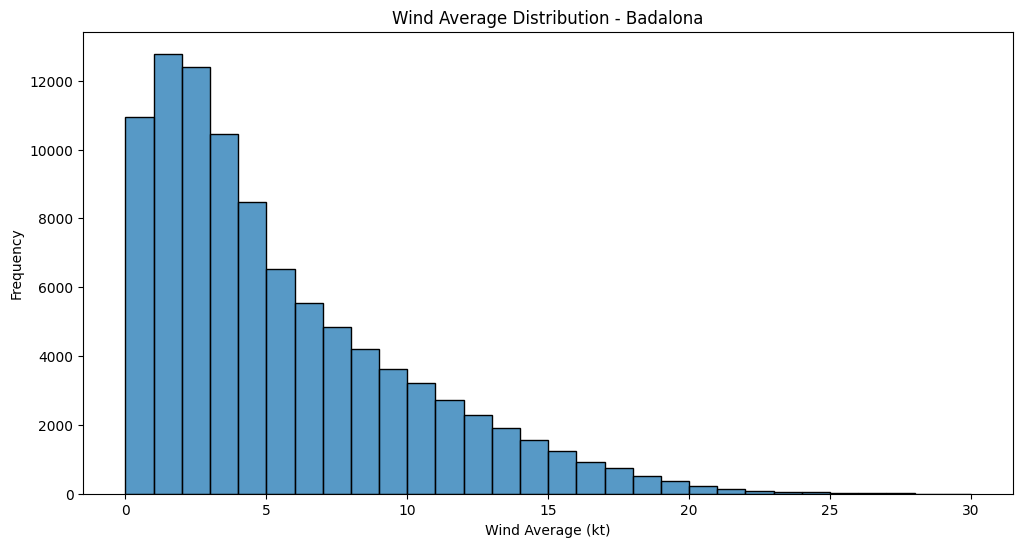

In [12]:
# ============================================================
# HISTOGRAMA VIENTO MEDIO
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

sns.histplot(
    data=df,
    x="wind_avg",
    bins=30,
    ax=ax
)

ax.set_title("Wind Average Distribution - Badalona")

ax.set_xlabel("Wind Average (kt)")

ax.set_ylabel("Frequency")

plt.show()

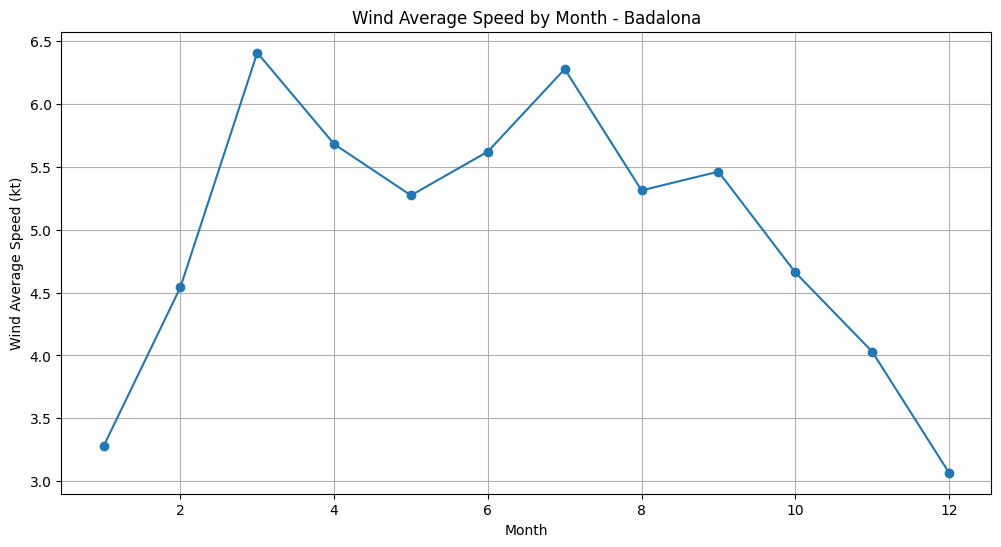

In [13]:
# ============================================================
# VIENTO MEDIO POR MES
# ============================================================

monthly_wind = (
    df.groupby("month")["wind_avg"]
    .mean()
)

fig, ax = plt.subplots(figsize=(12, 6))

monthly_wind.plot(
    marker="o",
    ax=ax
)

ax.set_title("Wind Average Speed by Month - Badalona")

ax.set_xlabel("Month")

ax.set_ylabel("Wind Average Speed (kt)")

ax.grid(True)

plt.show()

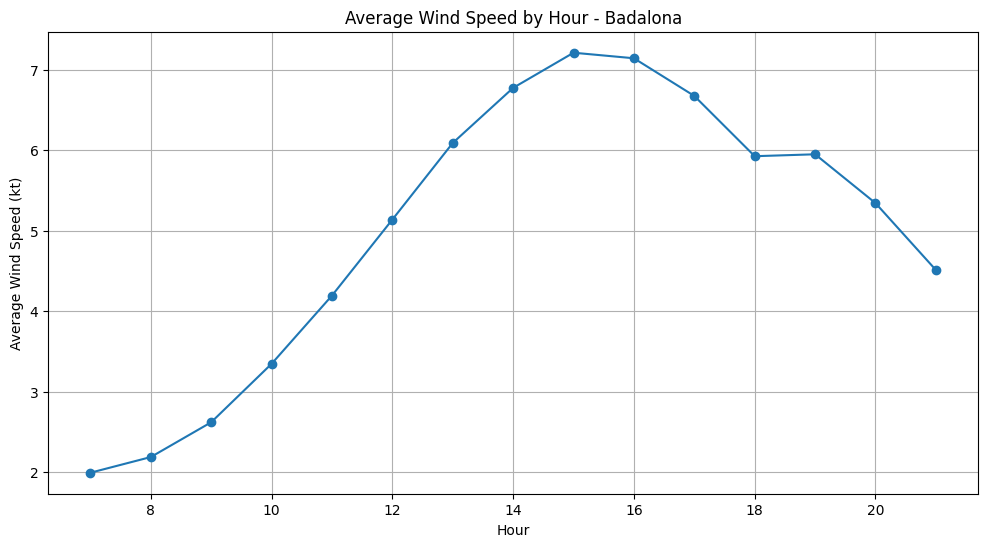

In [14]:
# ============================================================
# AVERAGE WIND SPEED BY HOUR
# ============================================================

hourly_wind = (
    df.groupby("hour")["wind_avg"]
    .mean()
)

fig, ax = plt.subplots(figsize=(12, 6))

hourly_wind.plot(
    marker="o",
    ax=ax
)

ax.set_title("Average Wind Speed by Hour - Badalona")

ax.set_xlabel("Hour")

ax.set_ylabel("Average Wind Speed (kt)")

ax.grid(True)

plt.show()

In [15]:
# ============================================================
# FILTER THERMAL WIND DIRECTIONS
# ============================================================

thermal_df = df[
    (df["wind_direction_deg"] >= 180) &
    (df["wind_direction_deg"] <= 225)
].copy()


print(thermal_df.shape)

thermal_df.head()

(17211, 14)


,datetime,spot,temperature,wind_direction_deg,wind_avg,wind_min,wind_max,unknown,source_file,year,month,day,hour,weekday
76,2021-01-02 14:00:07,BDLONA,10,220,1,0,3,1,210102.log,2021,1,2,14,Saturday
100,2021-01-03 07:45:08,BDLONA,7,207,2,0,6,1,210103.log,2021,1,3,7,Sunday
123,2021-01-03 13:45:10,BDLONA,9,219,2,0,7,1,210103.log,2021,1,3,13,Sunday
125,2021-01-03 14:30:06,BDLONA,10,218,2,0,9,1,210103.log,2021,1,3,14,Sunday
127,2021-01-03 15:00:03,BDLONA,10,221,2,0,6,1,210103.log,2021,1,3,15,Sunday


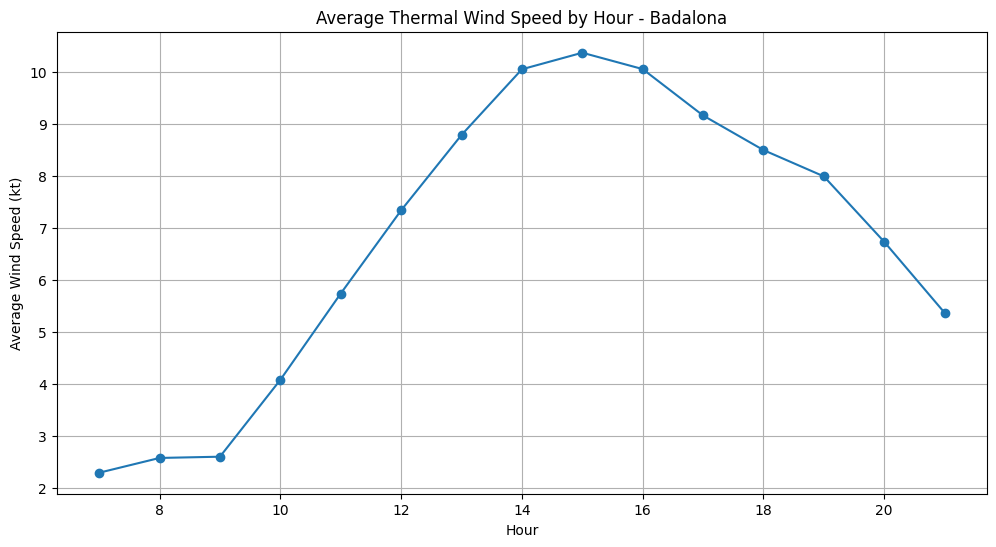

In [16]:
# ============================================================
# AVERAGE THERMAL WIND SPEED BY HOUR
# ============================================================

hourly_thermal_wind = (
    thermal_df.groupby("hour")["wind_avg"]
    .mean()
)

fig, ax = plt.subplots(figsize=(12, 6))

hourly_thermal_wind.plot(
    marker="o",
    ax=ax
)

ax.set_title("Average Thermal Wind Speed by Hour - Badalona")

ax.set_xlabel("Hour")

ax.set_ylabel("Average Wind Speed (kt)")

ax.grid(True)

plt.show()

In [19]:
# ============================================================
# CREATE SEASON FEATURE
# ============================================================

def get_season(month):

    if month in [12, 1, 2]:
        return "Winter"

    elif month in [3, 4, 5]:
        return "Spring"

    elif month in [6, 7, 8]:
        return "Summer"

    else:
        return "Autumn"


df["season"] = df["month"].apply(get_season)

thermal_df["season"] = thermal_df["month"].apply(get_season)


# ============================================================
# CHECK RESULT
# ============================================================

df[["month", "season"]].head()

,month,season
0,1,Winter
1,1,Winter
2,1,Winter
3,1,Winter
4,1,Winter


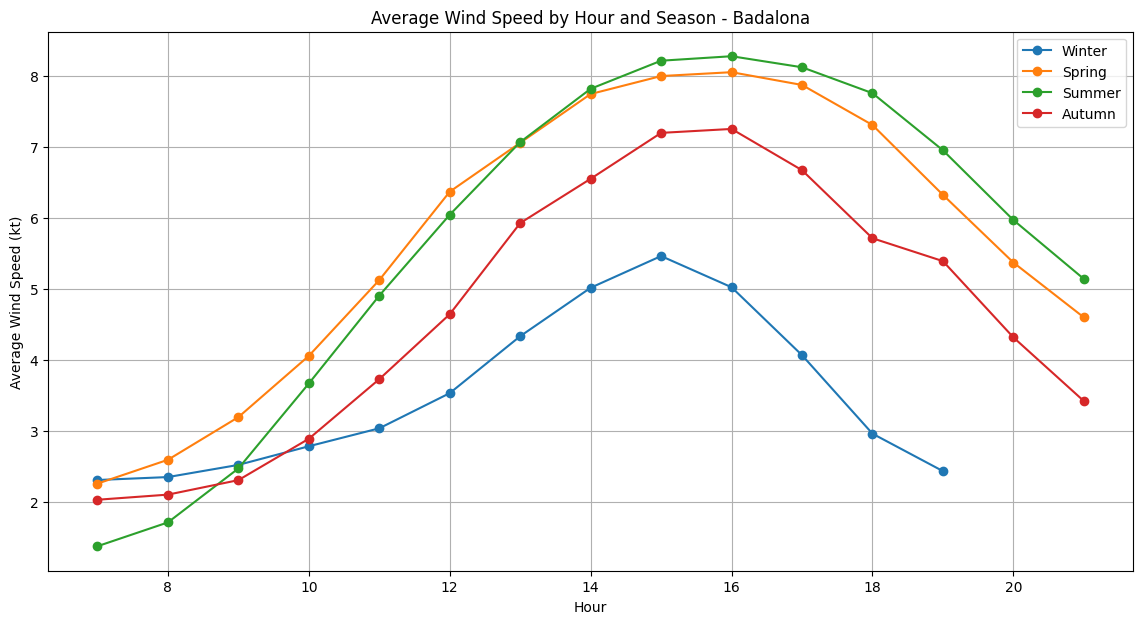

In [20]:
# ============================================================
# AVERAGE WIND SPEED BY HOUR AND SEASON
# ============================================================

seasonal_hourly_wind = (
    df.groupby(["season", "hour"])["wind_avg"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 7))

for season in ["Winter", "Spring", "Summer", "Autumn"]:

    season_data = seasonal_hourly_wind[
        seasonal_hourly_wind["season"] == season
    ]

    ax.plot(
        season_data["hour"],
        season_data["wind_avg"],
        marker="o",
        label=season
    )

ax.set_title("Average Wind Speed by Hour and Season - Badalona")

ax.set_xlabel("Hour")

ax.set_ylabel("Average Wind Speed (kt)")

ax.legend()

ax.grid(True)

plt.show()

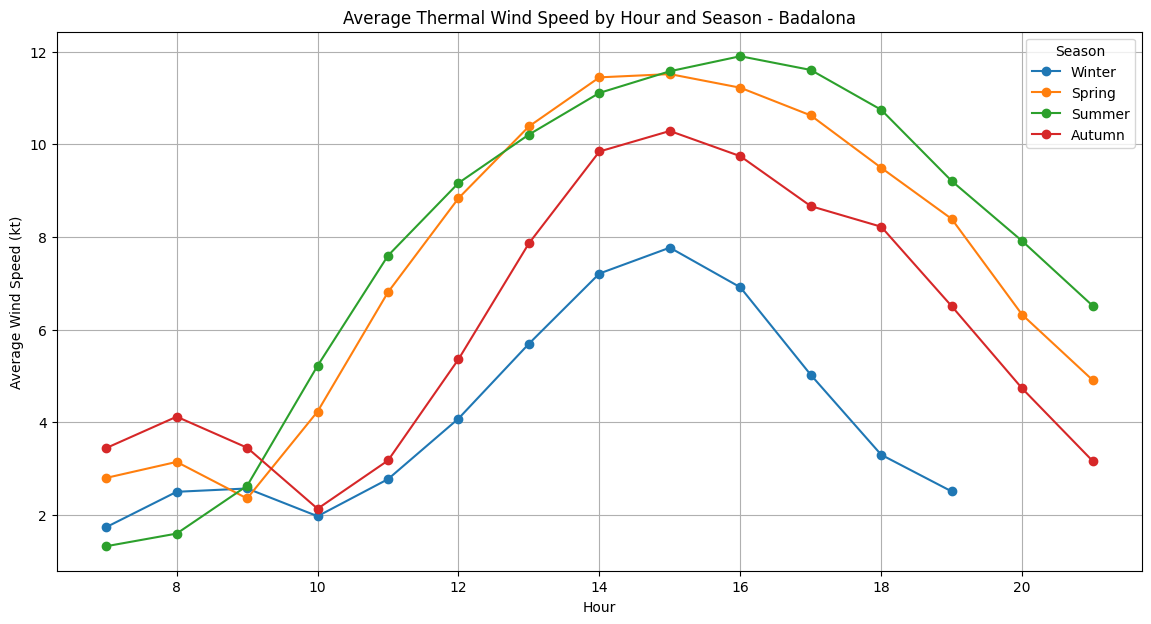

In [21]:
# ============================================================
# AVERAGE THERMAL WIND SPEED BY HOUR AND SEASON
# ============================================================

seasonal_thermal_hourly_wind = (
    thermal_df.groupby(["season", "hour"])["wind_avg"]
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 7))

for season in ["Winter", "Spring", "Summer", "Autumn"]:

    season_data = seasonal_thermal_hourly_wind[
        seasonal_thermal_hourly_wind["season"] == season
    ]

    ax.plot(
        season_data["hour"],
        season_data["wind_avg"],
        marker="o",
        label=season
    )

ax.set_title("Average Thermal Wind Speed by Hour and Season - Badalona")

ax.set_xlabel("Hour")

ax.set_ylabel("Average Wind Speed (kt)")

ax.legend(title="Season")

ax.grid(True)

plt.show()

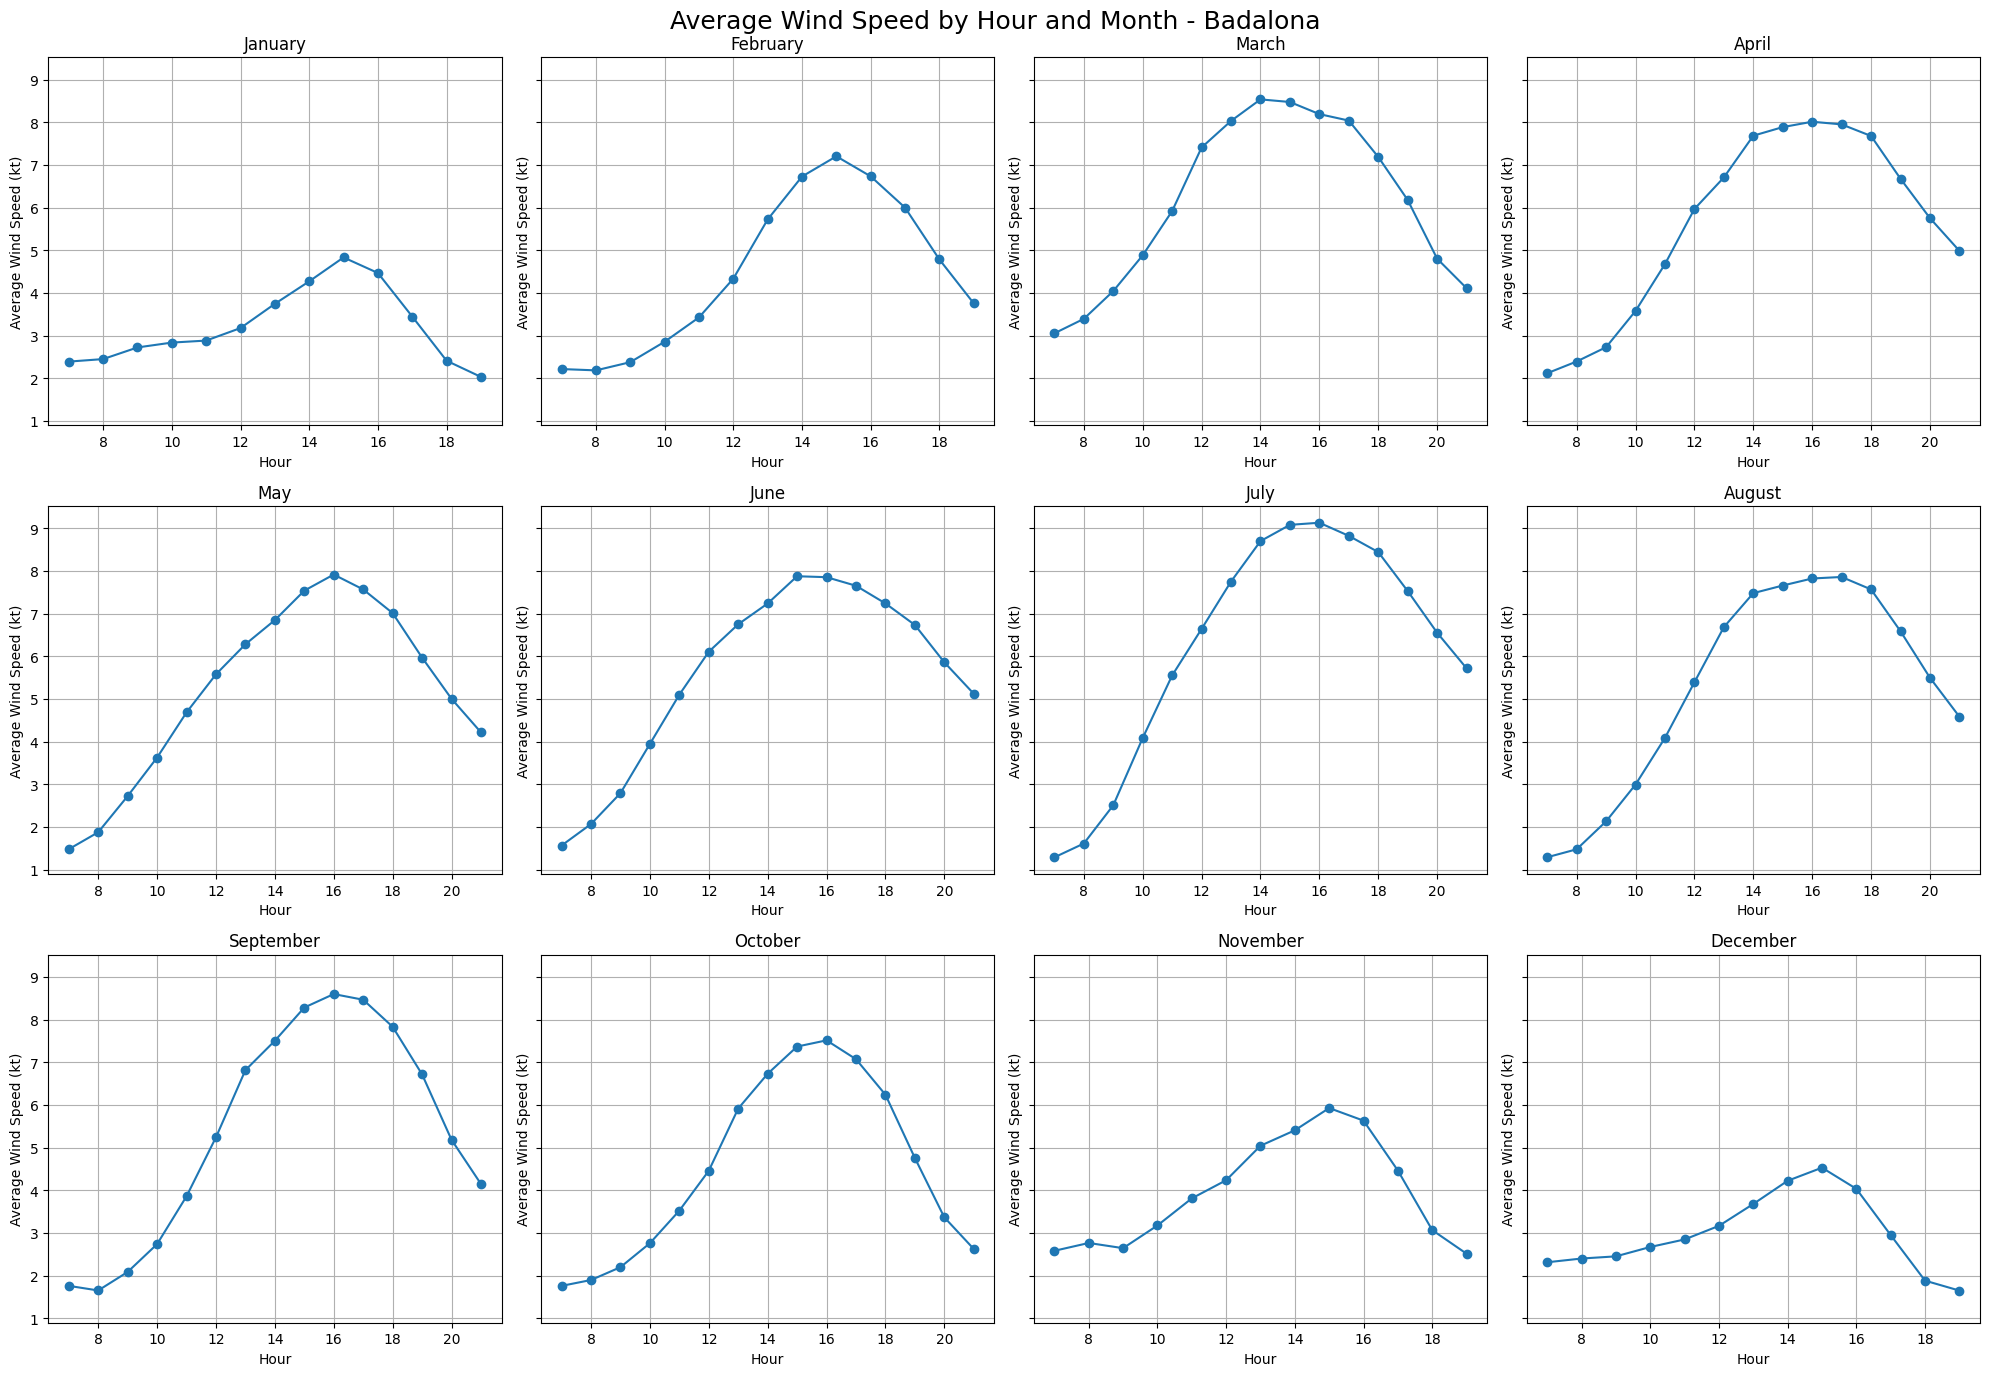

In [22]:
# ============================================================
# AVERAGE WIND SPEED BY HOUR AND MONTH
# ALL WINDS
# ============================================================

monthly_hourly_wind = (
    df.groupby(["month", "hour"])["wind_avg"]
    .mean()
    .reset_index()
)

# ============================================================
# CREATE SUBPLOTS
# ============================================================

fig, axes = plt.subplots(
    nrows=3,
    ncols=4,
    figsize=(20, 14),
    sharey=True
)

# Flatten axes for easy iteration
axes = axes.flatten()

# Month names
month_names = {
    1: "January",
    2: "February",
    3: "March",
    4: "April",
    5: "May",
    6: "June",
    7: "July",
    8: "August",
    9: "September",
    10: "October",
    11: "November",
    12: "December"
}

# ============================================================
# PLOT EACH MONTH
# ============================================================

for month in range(1, 13):

    ax = axes[month - 1]

    month_data = monthly_hourly_wind[
        monthly_hourly_wind["month"] == month
    ]

    ax.plot(
        month_data["hour"],
        month_data["wind_avg"],
        marker="o"
    )

    ax.set_title(month_names[month])

    ax.set_xlabel("Hour")

    ax.set_ylabel("Average Wind Speed (kt)")

    ax.grid(True)

# ============================================================
# GLOBAL TITLE
# ============================================================

fig.suptitle(
    "Average Wind Speed by Hour and Month - Badalona",
    fontsize=18
)

plt.tight_layout()

plt.show()

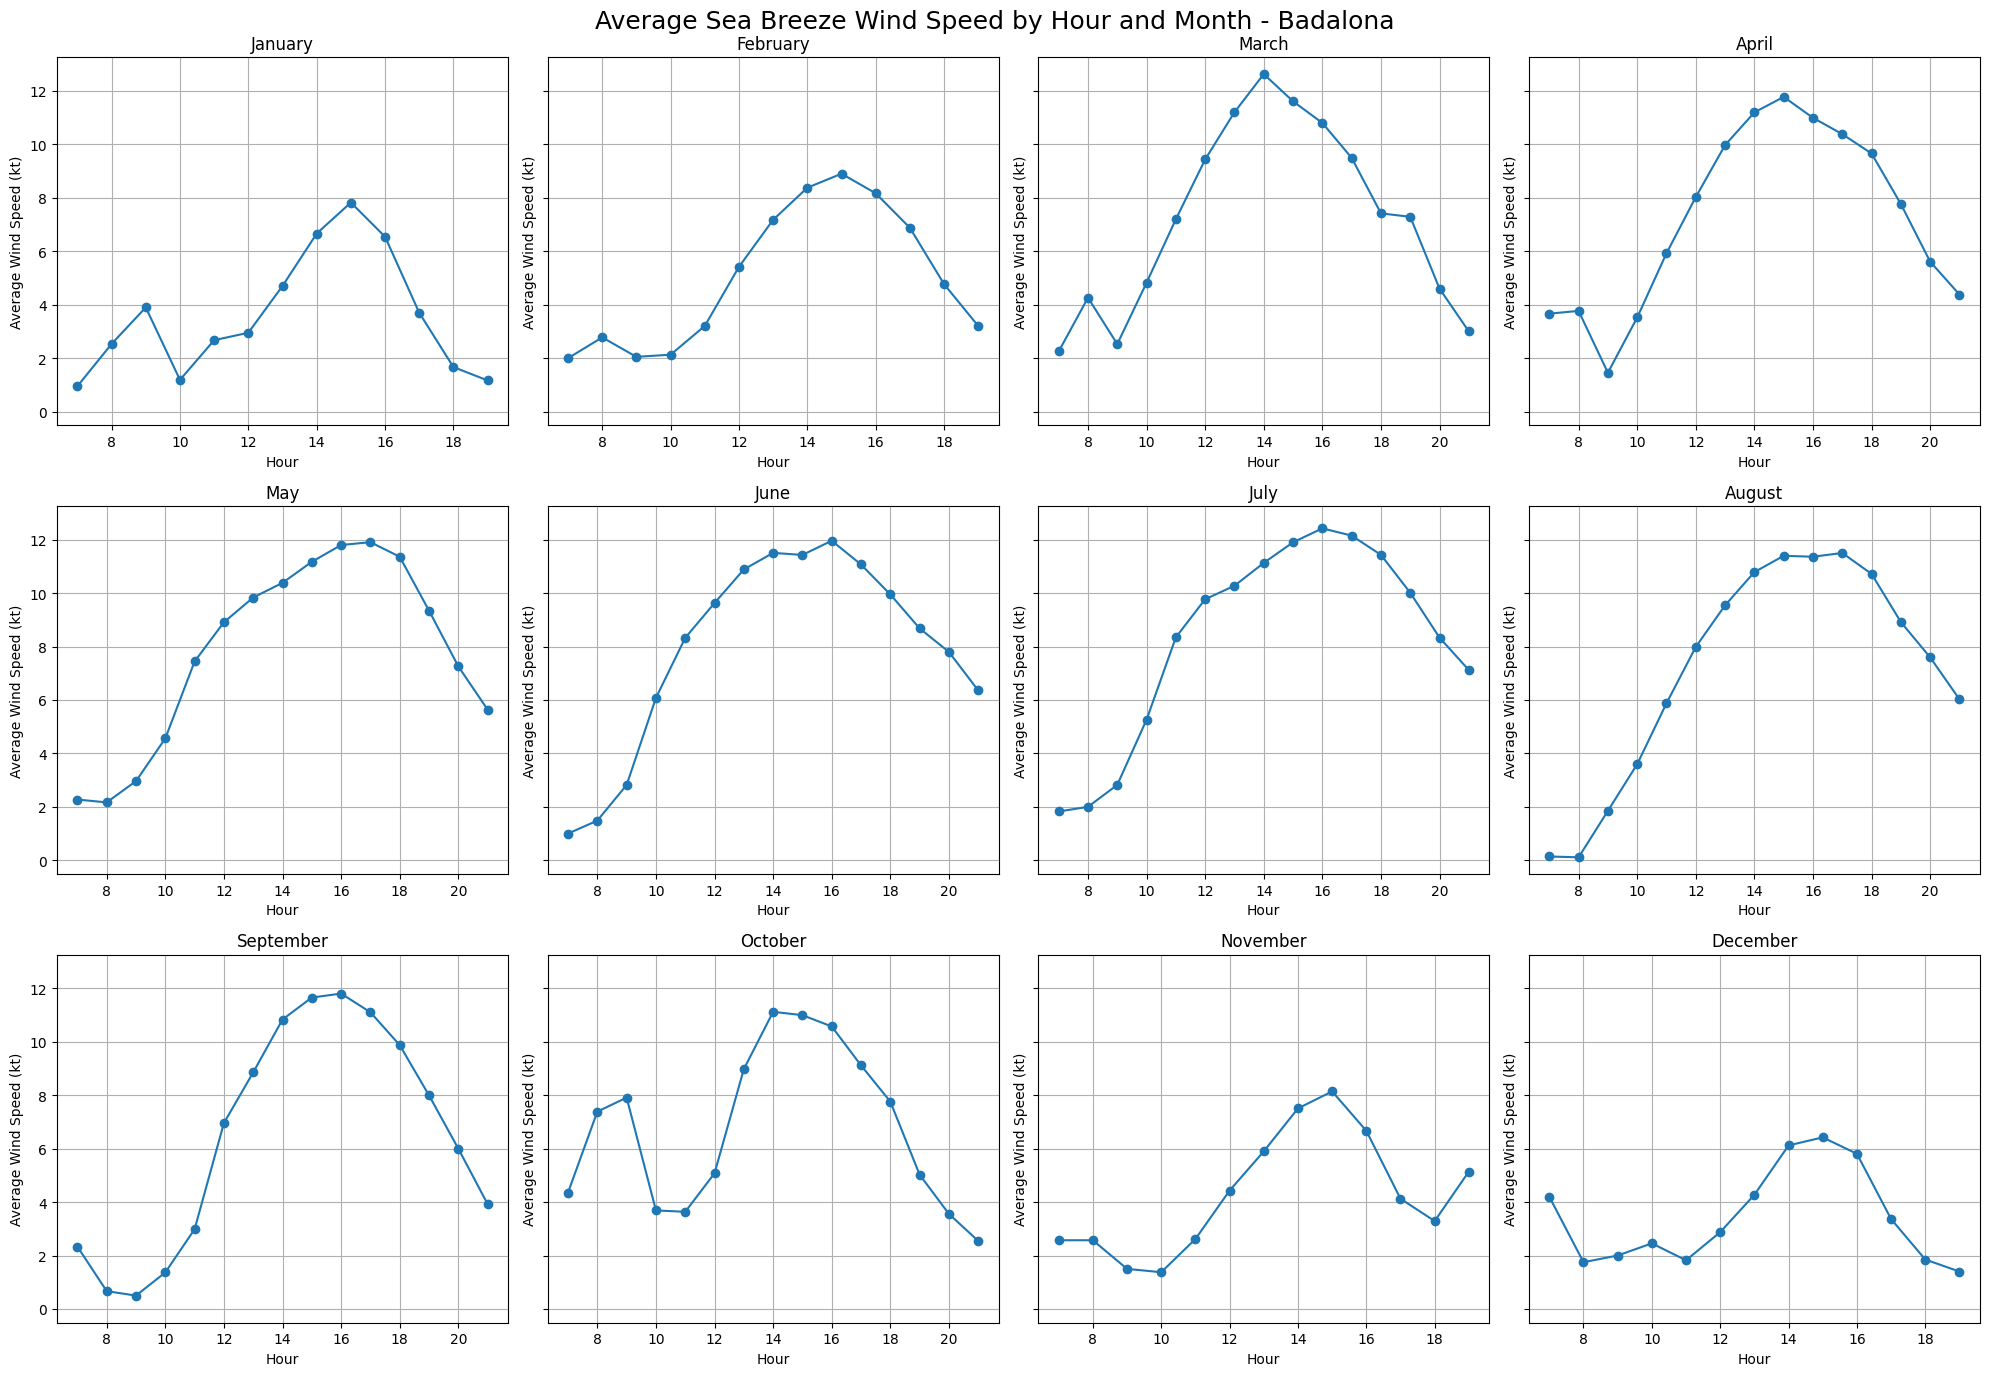

In [23]:
# ============================================================
# AVERAGE SEA BREEZE WIND SPEED BY HOUR AND MONTH
# ============================================================

monthly_hourly_sea_breeze = (
    thermal_df.groupby(["month", "hour"])["wind_avg"]
    .mean()
    .reset_index()
)

# ============================================================
# CREATE SUBPLOTS
# ============================================================

fig, axes = plt.subplots(
    nrows=3,
    ncols=4,
    figsize=(20, 14),
    sharey=True
)

# Flatten axes
axes = axes.flatten()

# Month names
month_names = {
    1: "January",
    2: "February",
    3: "March",
    4: "April",
    5: "May",
    6: "June",
    7: "July",
    8: "August",
    9: "September",
    10: "October",
    11: "November",
    12: "December"
}

# ============================================================
# PLOT EACH MONTH
# ============================================================

for month in range(1, 13):

    ax = axes[month - 1]

    month_data = monthly_hourly_sea_breeze[
        monthly_hourly_sea_breeze["month"] == month
    ]

    ax.plot(
        month_data["hour"],
        month_data["wind_avg"],
        marker="o"
    )

    ax.set_title(month_names[month])

    ax.set_xlabel("Hour")

    ax.set_ylabel("Average Wind Speed (kt)")

    ax.grid(True)

# ============================================================
# GLOBAL TITLE
# ============================================================

fig.suptitle(
    "Average Sea Breeze Wind Speed by Hour and Month - Badalona",
    fontsize=18
)

plt.tight_layout()

plt.show()

In [24]:
# ============================================================
# OTHER WIND DIRECTIONS
# ============================================================

other_wind_df = df[
    ~(
        (df["wind_direction_deg"] >= 180) &
        (df["wind_direction_deg"] <= 225)
    )
].copy()


print(other_wind_df.shape)

(78667, 15)


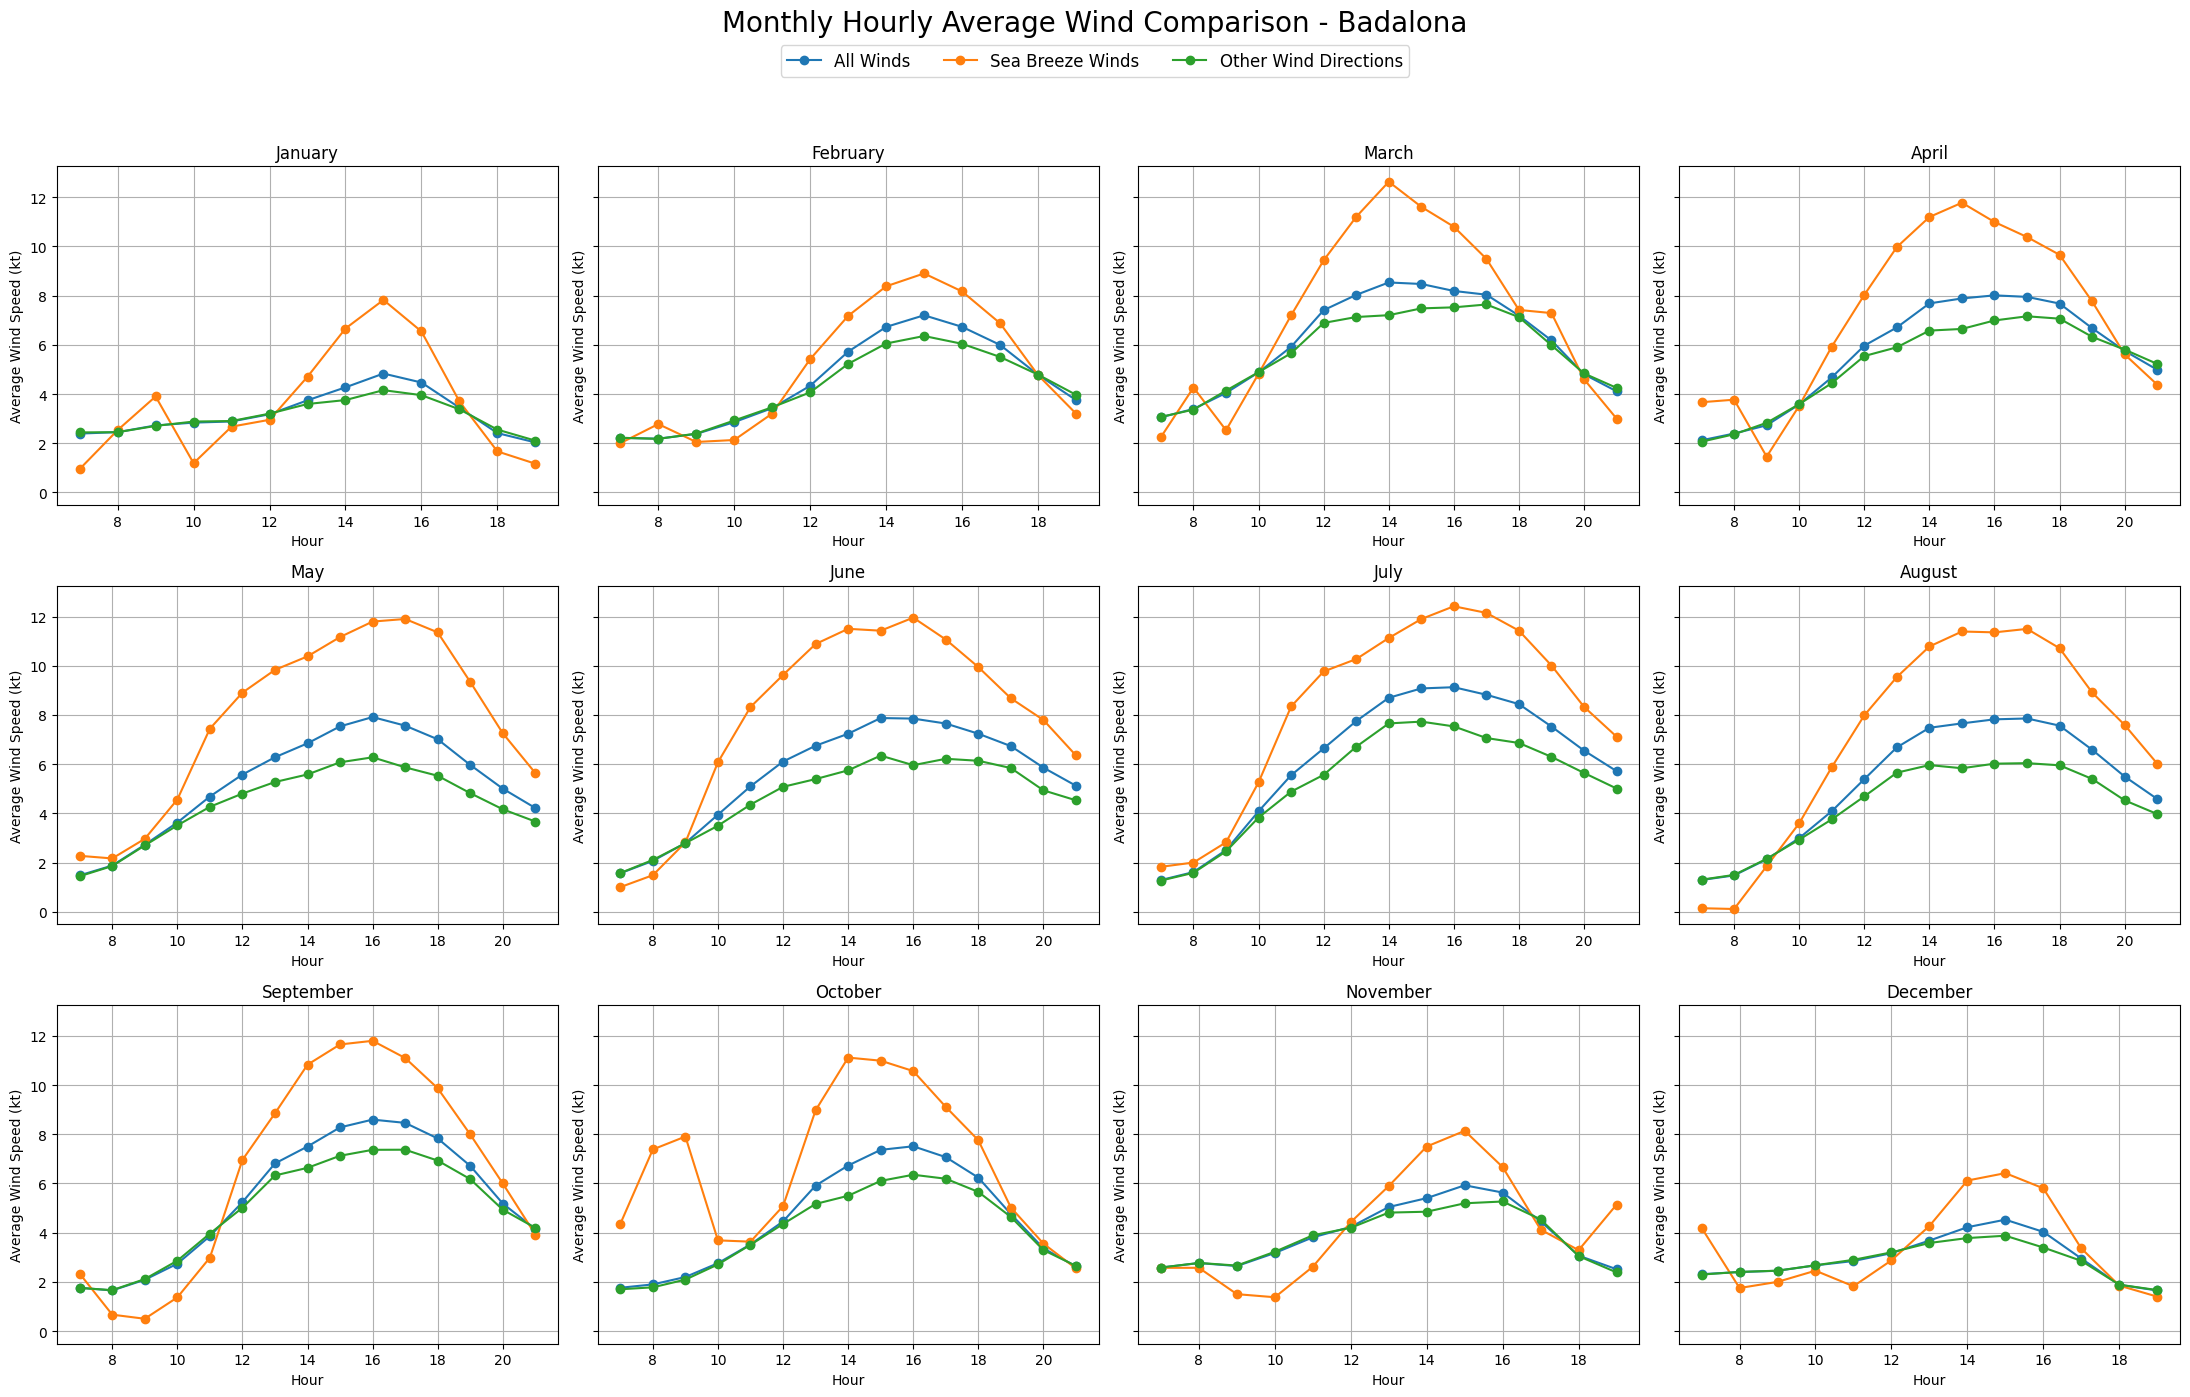

In [26]:
# ============================================================
# MONTHLY HOURLY WIND COMPARISON
# ALL WINDS vs SEA BREEZE vs OTHER DIRECTIONS
# ============================================================

# ============================================================
# GROUP DATA
# ============================================================

all_monthly = (
    df.groupby(["month", "hour"])["wind_avg"]
    .mean()
    .reset_index()
)

sea_breeze_monthly = (
    thermal_df.groupby(["month", "hour"])["wind_avg"]
    .mean()
    .reset_index()
)

other_monthly = (
    other_wind_df.groupby(["month", "hour"])["wind_avg"]
    .mean()
    .reset_index()
)

# ============================================================
# CREATE SUBPLOTS
# ============================================================

fig, axes = plt.subplots(
    nrows=3,
    ncols=4,
    figsize=(22, 14),
    sharey=True
)

axes = axes.flatten()

# ============================================================
# MONTH NAMES
# ============================================================

month_names = {
    1: "January",
    2: "February",
    3: "March",
    4: "April",
    5: "May",
    6: "June",
    7: "July",
    8: "August",
    9: "September",
    10: "October",
    11: "November",
    12: "December"
}

# ============================================================
# PLOT EACH MONTH
# ============================================================

for month in range(1, 13):

    ax = axes[month - 1]

    # -------------------------
    # ALL WINDS
    # -------------------------

    all_data = all_monthly[
        all_monthly["month"] == month
    ]

    ax.plot(
        all_data["hour"],
        all_data["wind_avg"],
        marker="o",
        label="All Winds"
    )

    # -------------------------
    # SEA BREEZE WINDS
    # -------------------------

    sea_data = sea_breeze_monthly[
        sea_breeze_monthly["month"] == month
    ]

    ax.plot(
        sea_data["hour"],
        sea_data["wind_avg"],
        marker="o",
        label="Sea Breeze Winds"
    )

    # -------------------------
    # OTHER WIND DIRECTIONS
    # -------------------------

    other_data = other_monthly[
        other_monthly["month"] == month
    ]

    ax.plot(
        other_data["hour"],
        other_data["wind_avg"],
        marker="o",
        label="Other Wind Directions"
    )

    # -------------------------
    # TITLES & LABELS
    # -------------------------

    ax.set_title(month_names[month])

    ax.set_xlabel("Hour")

    ax.set_ylabel("Average Wind Speed (kt)")

    ax.grid(True)

# ============================================================
# GLOBAL TITLE
# ============================================================

fig.suptitle(
    "Monthly Hourly Average Wind Comparison - Badalona",
    fontsize=20,
    y=0.995
)

# ============================================================
# GLOBAL LEGEND
# ============================================================

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.975),
    ncol=3,
    fontsize=12
)

# ============================================================
# LAYOUT
# ============================================================

plt.tight_layout(rect=[0, 0, 1, 0.94])

plt.show()

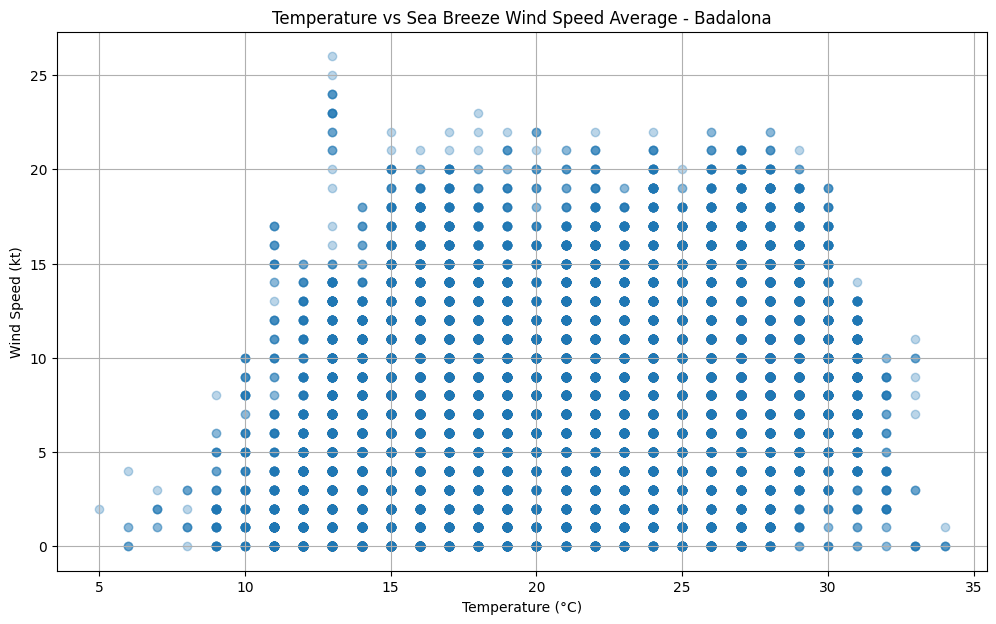

In [28]:
# ============================================================
# TEMPERATURE VS SEA BREEZE WIND SPEED
# ============================================================

fig, ax = plt.subplots(figsize=(12, 7))

ax.scatter(
    thermal_df["temperature"],
    thermal_df["wind_avg"],
    alpha=0.3
)

ax.set_title(
    "Temperature vs Sea Breeze Wind Speed Average - Badalona"
)

ax.set_xlabel("Temperature (°C)")

ax.set_ylabel("Wind Speed (kt)")

ax.grid(True)

plt.show()

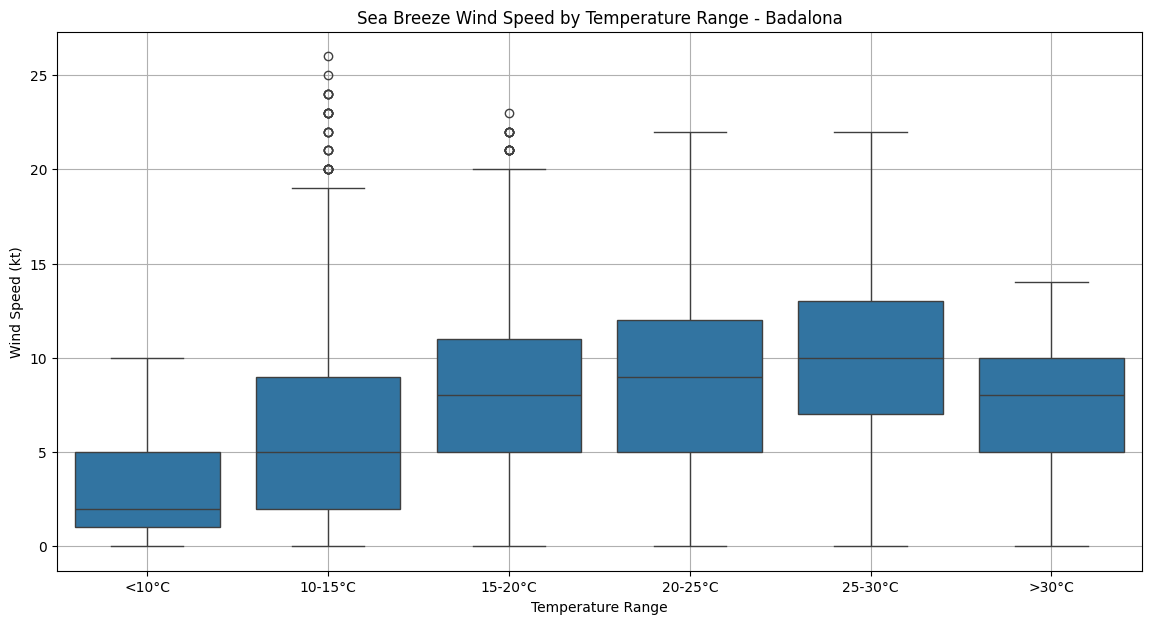

In [29]:
# ============================================================
# TEMPERATURE BINS
# ============================================================

temperature_bins = [0, 10, 15, 20, 25, 30, 40]

temperature_labels = [
    "<10°C",
    "10-15°C",
    "15-20°C",
    "20-25°C",
    "25-30°C",
    ">30°C"
]

thermal_df["temperature_range"] = pd.cut(
    thermal_df["temperature"],
    bins=temperature_bins,
    labels=temperature_labels
)

# ============================================================
# BOXPLOT
# TEMPERATURE VS SEA BREEZE WIND SPEED
# ============================================================

fig, ax = plt.subplots(figsize=(14, 7))

sns.boxplot(
    data=thermal_df,
    x="temperature_range",
    y="wind_avg",
    ax=ax
)

ax.set_title(
    "Sea Breeze Wind Speed by Temperature Range - Badalona"
)

ax.set_xlabel("Temperature Range")

ax.set_ylabel("Wind Speed (kt)")

ax.grid(True)

plt.show()